In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway, kruskal

sns.set(style="whitegrid")

In [5]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")


df = pd.concat([ethiopia, nigeria, sudan, tanzania, kenya], ignore_index=True)

df.head()
df["Country"].value_counts()
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
DATE           0
Month          0
dtype: int64

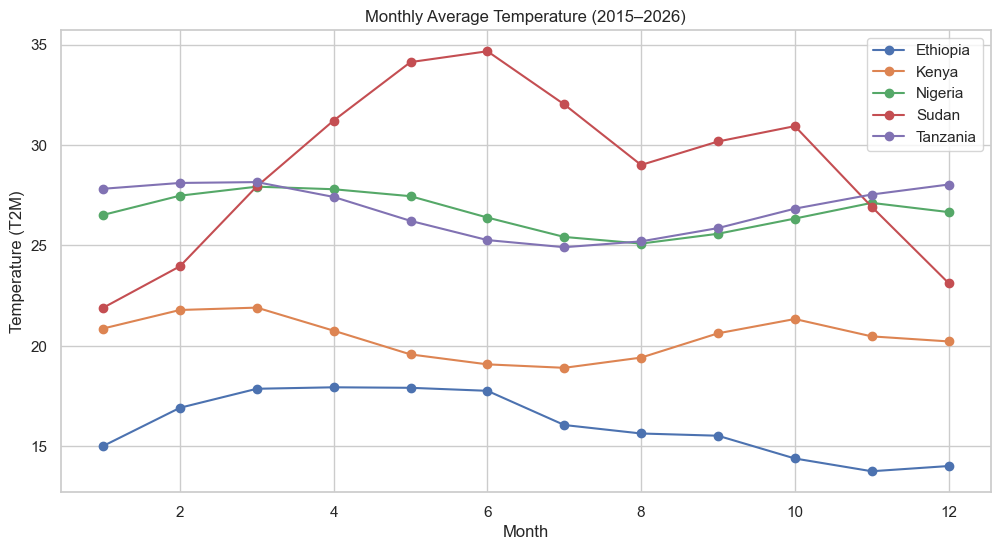

In [6]:
monthly_temp = df.groupby(["Country", "Month"])["T2M"].mean().reset_index()


plt.figure(figsize=(12,6))

for country in monthly_temp["Country"].unique():
    subset = monthly_temp[monthly_temp["Country"] == country]
    plt.plot(subset["Month"], subset["T2M"], marker='o', label=country)

plt.title("Monthly Average Temperature (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()

In [7]:
temp_summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
temp_summary

,mean,median,std
Country,,,
Ethiopia,16.068500,16.04,1.898050
Kenya,20.427600,20.36,1.440824
Nigeria,26.656928,26.82,1.123335
Sudan,28.759007,29.16,4.681305
Tanzania,26.802422,26.99,1.325388


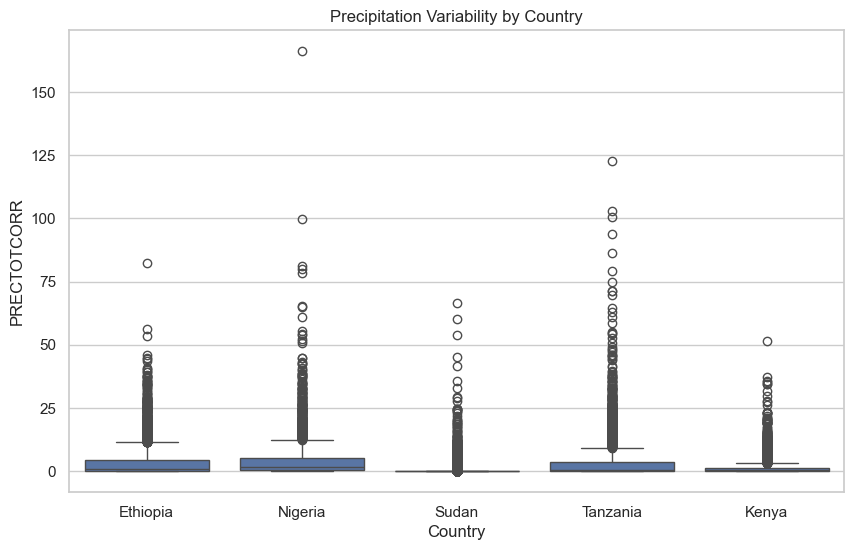

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Country", y="PRECTOTCORR")

plt.title("Precipitation Variability by Country")
plt.ylabel("PRECTOTCORR")
plt.show()

In [9]:
precip_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
precip_summary

,mean,median,std
Country,,,
Ethiopia,3.633795,0.82,6.289061
Kenya,1.468162,0.38,3.180228
Nigeria,4.213914,1.84,7.266742
Sudan,0.643875,0.00,3.057672
Tanzania,3.740256,0.64,8.003947


In [10]:
extreme_heat = df[df["T2M_MAX"] > 35]

heat_counts = extreme_heat.groupby(["Country", "YEAR"]).size().reset_index(name="Extreme_Heat_Days")

heat_counts.head()


,Country,YEAR,Extreme_Heat_Days
0,Sudan,2015,280
1,Sudan,2016,252
2,Sudan,2017,266
3,Sudan,2018,248
4,Sudan,2019,251


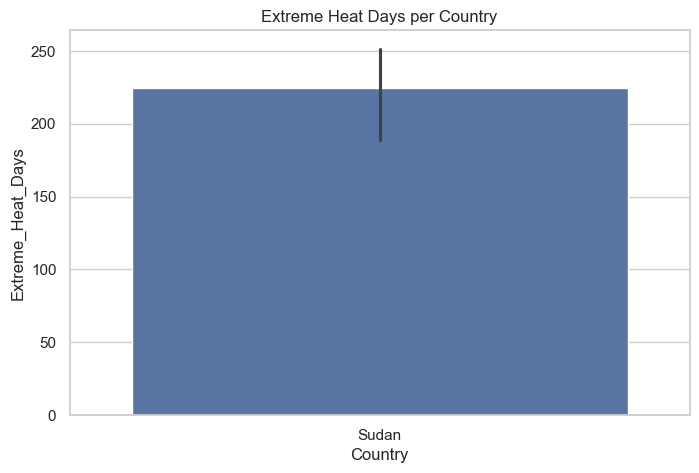

In [15]:
plt.figure(figsize=(8,5))
sns.barplot(data=heat_counts, x="Country", y="Extreme_Heat_Days")

plt.title("Extreme Heat Days per Country")
plt.show() 

In [12]:
dry_days = df[df["PRECTOTCORR"] < 1]

dry_counts = dry_days.groupby(["Country", "YEAR"]).size().reset_index(name="Dry_Days")

dry_counts.head()

,Country,YEAR,Dry_Days
0,Ethiopia,2015,215
1,Ethiopia,2016,176
2,Ethiopia,2017,190
3,Ethiopia,2018,194
4,Ethiopia,2019,186


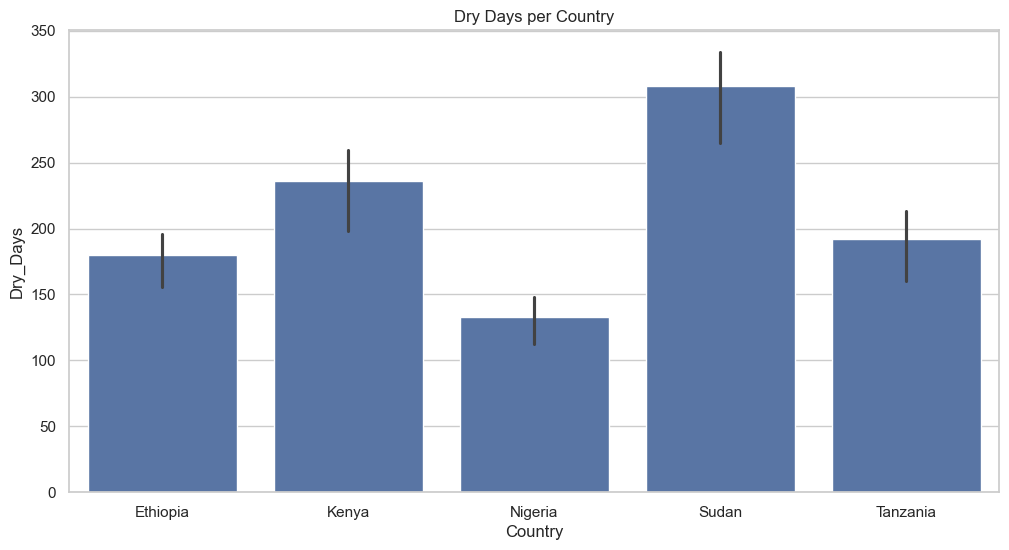

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(data=dry_counts, x="Country", y="Dry_Days")

plt.title("Dry Days per Country")
plt.show() 

In [16]:
groups = [df[df["Country"] == c]["T2M"] for c in df["Country"].unique()]

anova_result = f_oneway(*groups)

print("ANOVA p-value:", anova_result.pvalue)

ANOVA p-value: 0.0


p-value < 0.05: The differences in temperature between countries are statistically significant.

In [ ]:
vulnerability = df.groupby("Country").agg({
    "T2M": "mean",
    "PRECTOTCORR": "std"
}).rename(columns={
    "T2M": "Avg_Temp",
    "PRECTOTCORR": "Rainfall_Variability"
})

heat_total = extreme_heat.groupby("Country").size()

dry_total = dry_days.groupby("Country").size()

vulnerability["Extreme_Heat"] = heat_total
vulnerability["Dry_Days"] = dry_total

vulnerability = vulnerability.fillna(0)

vulnerability

,Avg_Temp,Rainfall_Variability,Extreme_Heat,Dry_Days
Country,,,,
Ethiopia,16.068500,6.289061,0.0,2161
Kenya,20.427600,3.180228,0.0,2831
Nigeria,26.656928,7.266742,0.0,1595
Sudan,28.759007,3.057672,2694.0,3696
Tanzania,26.802422,8.003947,0.0,2303


In [ ]:
vulnerability["Score"] = (
    vulnerability["Avg_Temp"] +
    vulnerability["Rainfall_Variability"] +
    vulnerability["Extreme_Heat"] +
    vulnerability["Dry_Days"]
)

ranking = vulnerability.sort_values(by="Score", ascending=False)

ranking

,Avg_Temp,Rainfall_Variability,Extreme_Heat,Dry_Days,Score
Country,,,,,
Sudan,28.759007,3.057672,2694.0,3696,6421.816679
Kenya,20.427600,3.180228,0.0,2831,2854.607828
Tanzania,26.802422,8.003947,0.0,2303,2337.806369
Ethiopia,16.068500,6.289061,0.0,2161,2183.357562
Nigeria,26.656928,7.266742,0.0,1595,1628.923670


### Climate Vulnerability Analysis for COP32

#### 1. Which country is warming fastest and what does the trend suggest?

Sudan is clearly the country experiencing the most intense warming. It has the highest average temperature (28.76°C) and also shows the largest temperature variability (standard deviation = 4.68), indicating strong fluctuations and extreme seasonal heat.

The temperature trend plot shows Sudan reaching peak values above 34°C during mid-year months, significantly higher than all other countries. 

This suggests that Sudan is undergoing severe warming and is highly exposed to heat stress, increasing risks to human health, agriculture, and water resources.

---

#### 2. Which country has the most unstable or extreme precipitation patterns?

Tanzania has the most unstable precipitation patterns, with the highest rainfall variability (standard deviation = 8.00), followed by Nigeria (7.27).

The boxplot also shows Tanzania having a wide spread and many extreme outliers, indicating irregular rainfall with both heavy precipitation events and dry periods.

This level of variability suggests a high risk of both flooding and drought, making rainfall patterns unpredictable and difficult to manage.

---

#### 3. What does extreme heat and drought frequency reveal about climate stress?

Extreme heat and drought data show that Sudan is under the highest climate stress.

- Sudan records extremely high numbers of extreme heat days (over 250 days per year in some cases)
- It also has the highest number of dry days (3696 total)

This combination indicates a severe climate environment characterized by persistent heatwaves and prolonged drought conditions.

In contrast, countries like Nigeria have fewer dry days (1595), suggesting relatively lower drought stress.

Overall, high extreme heat and dry day frequency directly correlate with increased climate vulnerability, especially in Sudan.

---

#### 4. How does Ethiopia's climate profile compare to its neighbors?

Ethiopia shows moderate climate vulnerability compared to its neighbors.

- It has the lowest average temperature (16.07°C), indicating less exposure to extreme heat
- However, it has relatively high rainfall variability (6.29), suggesting some instability in precipitation
- It also experiences a significant number of dry days (2161), indicating drought risk

Compared to Sudan and Kenya, Ethiopia is less extreme, but compared to Nigeria, it experiences more dryness.

Overall, Ethiopia faces moderate climate stress, with particular concern around water availability and rainfall inconsistency.

---

#### 5. Which country should Ethiopia champion for priority climate finance at COP32, and why?

Sudan should be prioritized for climate finance support at COP32.

The data strongly supports this conclusion:

- Highest average temperature (28.76°C)
- Extremely high temperature variability (std = 4.68)
- Highest number of extreme heat days (2694 total)
- Highest number of dry days (3696 total)

These indicators show that Sudan is experiencing the most severe combination of heat stress and drought conditions among all five countries.

This makes Sudan the most climate-vulnerable country in the analysis, and therefore the strongest candidate for targeted climate adaptation funding and international support.